# LLM Response Preference Prediction
## Predicting which AI response humans prefer (Model A wins, Model B wins, or Tie)



Importing all Relevant Libraries


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Sklearn: data splitting, preprocessing, evaluation ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# --- TensorFlow / Keras: for the LSTM baseline ---
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

# -----HuggingFace Transformers ---
import torch
from torch.utils.data import Dataset as TorchDataset

# --- NEW: seaborn for nicer confusion matrix heatmaps ---
import seaborn as sns

print("All libraries imported successfully.")
print(f"PyTorch version: {torch.__version__}")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available for PyTorch: {torch.cuda.is_available()}")

All libraries imported successfully.
PyTorch version: 2.10.0+cpu
TensorFlow version: 2.19.0
GPU available for PyTorch: False


 Reading all the data


In [12]:
train = pd.read_csv("train.csv", on_bad_lines='skip', engine='python')
test  = pd.read_csv("test.csv", on_bad_lines='skip', engine='python')

print("=== TRAIN ===")
print(f"Shape: {train.shape}")
print(f"Columns: {list(train.columns)}")

# NEW: also inspect the test set right away so we know what we're working toward
print("\n=== TEST ===")
print(f"Shape: {test.shape}")
print(f"Columns: {list(test.columns)}")

train.head()

=== TRAIN ===
Shape: (53366, 9)
Columns: ['id', 'model_a', 'model_b', 'prompt', 'response_a', 'response_b', 'winner_model_a', 'winner_model_b', 'winner_tie']

=== TEST ===
Shape: (3, 4)
Columns: ['id', 'prompt', 'response_a', 'response_b']


,id,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie
0,30192,gpt-4-1106-preview,gpt-4-0613,"[""Is it morally right to try to have a certain...","[""The question of whether it is morally right ...","[""As an AI, I don't have personal beliefs or o...",1,0,0
1,53567,koala-13b,gpt-4-0613,"[""What is the difference between marriage lice...","[""A marriage license is a legal document that ...","[""A marriage license and a marriage certificat...",0,1,0
2,65089,gpt-3.5-turbo-0613,mistral-medium,"[""explain function calling. how would you call...","[""Function calling is the process of invoking ...","[""Function calling is the process of invoking ...",0,0,1
3,96401,llama-2-13b-chat,mistral-7b-instruct,"[""How can I create a test set for a very rare ...","[""Creating a test set for a very rare category...","[""When building a classifier for a very rare c...",1,0,0
4,198779,koala-13b,gpt-3.5-turbo-0314,"[""What is the best way to travel from Tel-Aviv...","[""The best way to travel from Tel Aviv to Jeru...","[""The best way to travel from Tel-Aviv to Jeru...",0,1,0


It seems the `ParserError: EOF inside string` is persistent and indicates a severely malformed line that `pandas.read_csv` struggles to recover from, even with `engine='python'` and `on_bad_lines='skip'`. To get better control and explicitly remove these lines, we'll manually process the CSV file using Python's built-in `csv` module. This will allow us to identify and skip truly problematic lines.

In [13]:
import csv
import io

input_file = "train.csv"
output_file = "train_cleaned.csv"

bad_lines_count = 0
cleaned_lines = []

with open(input_file, 'r', encoding='utf-8', errors='replace') as infile:
    reader = csv.reader(infile)
    header = next(reader) # Read header
    cleaned_lines.append(header)

    # Attempt to read each row and catch errors
    for i, row_data in enumerate(reader):
        try:
            # Try to re-join the row data and then parse again for validation
            # This is a robust check for unclosed quotes that cause EOF errors
            test_row = io.StringIO()
            writer = csv.writer(test_row)
            writer.writerow(row_data)
            _ = next(csv.reader(io.StringIO(test_row.getvalue())))
            cleaned_lines.append(row_data)
        except csv.Error as e:
            print(f"Skipping malformed line {i + 2}: {e}") # +2 for 0-indexed and header
            bad_lines_count += 1
        except Exception as e:
            print(f"Skipping line {i + 2} due to unexpected error: {e}")
            bad_lines_count += 1

with open(output_file, 'w', encoding='utf-8', newline='') as outfile:
    writer = csv.writer(outfile)
    writer.writerows(cleaned_lines)

print(f"\nProcessed {input_file}.")
print(f"Found and skipped {bad_lines_count} malformed lines.")
print(f"Cleaned data saved to {output_file}.")



Processed train.csv.
Found and skipped 0 malformed lines.
Cleaned data saved to train_cleaned.csv.


Now that we have a cleaned `train_cleaned.csv` file, we can load it safely into a pandas DataFrame. We'll also load the `test.csv` as it seems to be fine.

In [14]:
train = pd.read_csv(output_file, on_bad_lines='skip', engine='python') # Use the cleaned file
test  = pd.read_csv("test.csv", on_bad_lines='skip', engine='python')

print("=== TRAIN ===")
print(f"Shape: {train.shape}")
print(f"Columns: {list(train.columns)}")

print("\n=== TEST ===")
print(f"Shape: {test.shape}")
print(f"Columns: {list(test.columns)}")

train.head()

=== TRAIN ===
Shape: (57477, 9)
Columns: ['id', 'model_a', 'model_b', 'prompt', 'response_a', 'response_b', 'winner_model_a', 'winner_model_b', 'winner_tie']

=== TEST ===
Shape: (3, 4)
Columns: ['id', 'prompt', 'response_a', 'response_b']


,id,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie
0,30192,gpt-4-1106-preview,gpt-4-0613,"[""Is it morally right to try to have a certain...","[""The question of whether it is morally right ...","[""As an AI, I don't have personal beliefs or o...",1,0,0
1,53567,koala-13b,gpt-4-0613,"[""What is the difference between marriage lice...","[""A marriage license is a legal document that ...","[""A marriage license and a marriage certificat...",0,1,0
2,65089,gpt-3.5-turbo-0613,mistral-medium,"[""explain function calling. how would you call...","[""Function calling is the process of invoking ...","[""Function calling is the process of invoking ...",0,0,1
3,96401,llama-2-13b-chat,mistral-7b-instruct,"[""How can I create a test set for a very rare ...","[""Creating a test set for a very rare category...","[""When building a classifier for a very rare c...",1,0,0
4,198779,koala-13b,gpt-3.5-turbo-0314,"[""What is the best way to travel from Tel-Aviv...","[""The best way to travel from Tel Aviv to Jeru...","[""The best way to travel from Tel-Aviv to Jeru...",0,1,0


 Understanding the targets


In [15]:
# The three target columns are one-hot style:
# winner_model_a = 1  =>  human preferred response A
# winner_model_b = 1  =>  human preferred response B
# winner_tie     = 1  =>  human said it was a tie
# Exactly one column is 1 per row.
train[['winner_model_a', 'winner_model_b', 'winner_tie']].head()

,winner_model_a,winner_model_b,winner_tie
0,1,0,0
1,0,1,0
2,0,0,1
3,1,0,0
4,0,1,0


 Collapsing the three target columns into one label


In [16]:
# Label mapping (we will reference this throughout):
#   0  =>  Model A wins
#   1  =>  Model B wins
#   2  =>  Tie
LABEL_NAMES = ['A wins', 'B wins', 'Tie']

def get_label(row):
    if row['winner_model_a'] == 1:
        return 0   # A wins
    elif row['winner_model_b'] == 1:
        return 1   # B wins
    else:
        return 2   # Tie

train['label'] = train.apply(get_label, axis=1)

train.head()

,id,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie,label
0,30192,gpt-4-1106-preview,gpt-4-0613,"[""Is it morally right to try to have a certain...","[""The question of whether it is morally right ...","[""As an AI, I don't have personal beliefs or o...",1,0,0,0
1,53567,koala-13b,gpt-4-0613,"[""What is the difference between marriage lice...","[""A marriage license is a legal document that ...","[""A marriage license and a marriage certificat...",0,1,0,1
2,65089,gpt-3.5-turbo-0613,mistral-medium,"[""explain function calling. how would you call...","[""Function calling is the process of invoking ...","[""Function calling is the process of invoking ...",0,0,1,2
3,96401,llama-2-13b-chat,mistral-7b-instruct,"[""How can I create a test set for a very rare ...","[""Creating a test set for a very rare category...","[""When building a classifier for a very rare c...",1,0,0,0
4,198779,koala-13b,gpt-3.5-turbo-0314,"[""What is the best way to travel from Tel-Aviv...","[""The best way to travel from Tel Aviv to Jeru...","[""The best way to travel from Tel-Aviv to Jeru...",0,1,0,1


Checking Class Balance


Label counts:
  0 (A wins): 20,064  (34.9%)
  1 (B wins): 19,652  (34.2%)
  2 (Tie): 17,761  (30.9%)


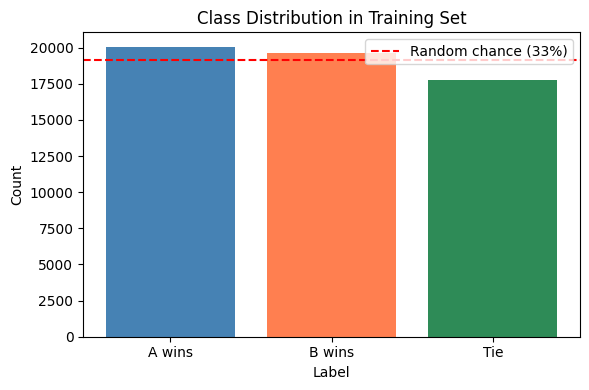


Random-chance baseline: 33.3%


In [17]:
counts = train['label'].value_counts().sort_index()
print("Label counts:")
for idx, count in counts.items():
    pct = count / len(train) * 100
    print(f"  {idx} ({LABEL_NAMES[idx]}): {count:,}  ({pct:.1f}%)")

# visual bar chart of class distribution
plt.figure(figsize=(6, 4))
plt.bar(LABEL_NAMES, counts.values, color=['steelblue', 'coral', 'seagreen'])
plt.title('Class Distribution in Training Set')
plt.ylabel('Count')
plt.xlabel('Label')
# Drawing a dashed line at the random-chance level (1/3 of total)
plt.axhline(len(train) / 3, color='red', linestyle='--', label='Random chance (33%)')
plt.legend()
plt.tight_layout()
plt.show()

# classes are roughly balanced (~35% / ~34% / ~31%)
# => random guessing gets ~33% accuracy
# => any model below 33% is WORSE than random
print(f"\nRandom-chance baseline: {100/3:.1f}%")

 Combining Prompt and Responses into one input string


In [21]:
# Concatenating the  prompt + both responses into a single string.
# The special tokens PROMPT:, RESPONSE_A:, RESPONSE_B: help the model
# distinguish the three parts during tokenisation.
train['input_text'] = (
    "PROMPT: "     + train['prompt'].astype(str) +
    " RESPONSE_A: " + train['response_a'].astype(str) +
    " RESPONSE_B: " + train['response_b'].astype(str)
)

# --- Split the data into training and validation sets for all models ---
# 80% train, 20% validation, random_state=42 for reproducibility
X_text, X_val_text, y_train, y_val = train_test_split(
    train['input_text'], train['label'], test_size=0.2, random_state=42
)

print(f"Overall Training text samples: {len(X_text):,}")
print(f"Overall Validation text samples: {len(X_val_text):,}")

# calculating how long on average the prompts are to properly determine MAX_LEN for LSTM
word_counts = train['input_text'].str.split().str.len()
print(f"Average words per input:  {word_counts.mean():.0f}")
print(f"Median words per input:   {word_counts.median():.0f}")
print(f"Max words per input:      {word_counts.max():,}")
print()

Overall Training text samples: 45,981
Overall Validation text samples: 11,496
Average words per input:  467
Median words per input:   374
Max words per input:      12,317



---
## BASELINE MODEL 1: TF-IDF + Logistic Regression


In [22]:
# --- Step 1: Convert raw text to TF-IDF feature vectors ---
# max_features=5000 keeps only the 5000 most informative word/bigrams
# ngram_range=(1,2) captures single words AND two-word phrases
# stop_words='english' removes common filler words (the, is, at...)
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english'
)

X_train_tfidf = vectorizer.fit_transform(X_text)
X_val_tfidf   = vectorizer.transform(X_val_text)

print(f"TF-IDF training feature matrix shape: {X_train_tfidf.shape}")
print(f"TF-IDF validation feature matrix shape: {X_val_tfidf.shape}")

TF-IDF training feature matrix shape: (45981, 5000)
TF-IDF validation feature matrix shape: (11496, 5000)


In [23]:
# --- Step 2: Assign TF-IDF features to X_train and X_val ---
# The train/validation split for text data and labels was already performed.
# Now, we assign the TF-IDF transformed features for the training of Logistic Regression.
X_train = X_train_tfidf
X_val   = X_val_tfidf

# y_train and y_val were already defined from the initial data split in a previous cell.

In [24]:
# --- Step 3: Train Logistic Regression ---
# max_iter=1000 ensures convergence on this size of data
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Evaluating the Baseline

=== Baseline 1: TF-IDF + Logistic Regression ===
Validation Accuracy: 0.3770
Random-chance baseline: 0.3333

Per-class breakdown:
              precision    recall  f1-score   support

      A wins       0.38      0.41      0.39      4030
      B wins       0.37      0.37      0.37      3929
         Tie       0.39      0.35      0.37      3537

    accuracy                           0.38     11496
   macro avg       0.38      0.38      0.38     11496
weighted avg       0.38      0.38      0.38     11496



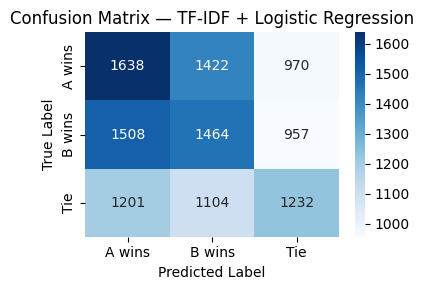

In [26]:
# --- Step 4: Evaluate Baseline 1 ---
lr_preds = lr_model.predict(X_val)

lr_accuracy = accuracy_score(y_val, lr_preds)
print(f"=== Baseline 1: TF-IDF + Logistic Regression ===")
print(f"Validation Accuracy: {lr_accuracy:.4f}")
print(f"Random-chance baseline: {1/3:.4f}")
print()

# NEW: classification_report — shows precision, recall, F1 per class
# This tells us: is the model equally bad at all classes, or worse on 'Tie'?
print("Per-class breakdown:")
print(classification_report(y_val, lr_preds, target_names=LABEL_NAMES))

# NEW: Confusion matrix — visualises which classes are being confused with which
cm = confusion_matrix(y_val, lr_preds)
plt.figure(figsize=(4 ,3))
sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES,
    cmap='Blues'
)
plt.title('Confusion Matrix — TF-IDF + Logistic Regression')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# INTERPRETATION GUIDE:
# Diagonal = correct predictions.
# Off-diagonal = where the model is confused.
# e.g. large value at row 'Tie', col 'A wins' means the model often
#      predicts 'A wins' when the true label is 'Tie'.

---
## BASELINE MODEL 2: Bidirectional LSTM


In [25]:
# --- Bidirectional LSTM ---
# This reads the sequence BOTH left→right AND right→left,
# effectively doubling the context the model sees at each timestep.

MAX_WORDS = 20000
MAX_LEN = 500

# Tokenizer fitted ONLY on training data (X_text)
bilstm_tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
bilstm_tokenizer.fit_on_texts(X_text)

X_train_seq = bilstm_tokenizer.texts_to_sequences(X_text)
X_val_seq   = bilstm_tokenizer.texts_to_sequences(X_val_text)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')

# Labels for LSTM are the same as overall y_train and y_val
y_train_bilstm = y_train
y_val_bilstm = y_val

print(f"Train shape: {X_train_pad.shape}")
print(f"Val shape:   {X_val_pad.shape}")

Train shape: (45981, 500)
Val shape:   (11496, 500)


In [30]:
from tensorflow.keras.layers import Bidirectional

bilstm_model = Sequential([
    # Embedding: token IDs → 128-dim dense vectors
    Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN),

    # Bidirectional LSTM: runs one LSTM forward (left→right) and one
    # backward (right→left), then concatenates their outputs.
    # Result: 256-dim hidden state (128 from each direction).
    Bidirectional(LSTM(128, return_sequences=False)),

    Dropout(0.4),          # slightly higher dropout than before to fight overfitting

    Dense(64, activation='relu'),
    Dropout(0.2),          # second dropout before final layer

    Dense(3, activation='softmax')
])

bilstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Stop training if val_loss stops improving for 2 consecutive epochs
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True,
    verbose=1
)

# Halve the learning rate if val_loss plateaus for 1 epoch
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-6,
    verbose=1
)

bilstm_history = bilstm_model.fit(
    X_train_pad, y_train_bilstm,
    validation_data=(X_val_pad, y_val_bilstm),
    epochs=6,              #  early stopping will pause everything if needed
    batch_size=32,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/6
  19/1437 ━━━━━━━━━━━━━━━━━━━━ 39:39 2s/step - accuracy: 0.3809 - loss: 1.0974

##Evaluating the BLSTM Model

In [28]:
loss, acc = bilstm_model.evaluate(X_val_pad, y_val_bilstm)
print(f"Val Accuracy: {acc:.4f}")

NameError: name 'bilstm_model' is not defined

In [29]:
# Making predictions on the validation set
bilstm_preds_prob = bilstm_model.predict(X_val_pad)
bilstm_preds      = np.argmax(bilstm_preds_prob, axis=1)

print("=== Bidirectional LSTM Evaluation ===")
print("Per-class breakdown:")
print(classification_report(y_val_bilstm, bilstm_preds, target_names=LABEL_NAMES))

# Confusion matrix
cm_bilstm = confusion_matrix(y_val_bilstm, bilstm_preds)
plt.figure(figsize=(4, 3))
sns.heatmap(
    cm_bilstm, annot=True, fmt='d',
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES,
    cmap='Oranges'
)
plt.title('Confusion Matrix — Bidirectional LSTM')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

NameError: name 'bilstm_model' is not defined

In [ ]:
import matplotlib.pyplot as plt

# Just print final validation metrics from history (no re-evaluation)
final_val_acc  = bilstm_history.history['val_accuracy'][-1]
final_val_loss = bilstm_history.history['val_loss'][-1]

print(f"Final Val Accuracy: {final_val_acc:.4f}")
print(f"Final Val Loss: {final_val_loss:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(bilstm_history.history['loss'], label='Train Loss')
ax1.plot(bilstm_history.history['val_loss'], label='Val Loss')
ax1.set_title('Loss Over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Accuracy plot
ax2.plot(bilstm_history.history['accuracy'], label='Train Accuracy')
ax2.plot(bilstm_history.history['val_accuracy'], label='Val Accuracy')
ax2.set_title('Accuracy Over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

---
## BASELINE COMPARISON SUMMARY


In [ ]:
# NEW: Side-by-side summary of both baselines
print("=" * 55)
print("BASELINE MODEL COMPARISON SUMMARY")
print("=" * 55)
print(f"{'Model':<35} {'Val Accuracy':>12}")
print("-" * 55)
print(f"{'Random chance (floor)':<35} {1/3:>12.4f}")
print(f"{'TF-IDF + Logistic Regression':<35} {lr_accuracy:>12.4f}")
print(f"{'bidectional LSTM (from scratch)':<35} {acc:>12.4f}")
print("=" * 55)
